# 7. Continuation — 그래서 다시 돌아왔는가

**분석 목적:** 초기 경험 이후의 능동 활동, 반복 활동, Hackle 단기 재방문을 구분하고 제품 개선 가설을 도출한다.

분석 순서: **측정 가능성 → 모집단·관측 범위 → DB 후속 활동 → 초기 경험과의 관계 → 반복·공백 후 복귀 → Hackle 재방문 → 제품 판단.**

입력은 `data/preprocessed mart`만 사용한다. 원본은 수정하지 않는다. 노트북의 모든 셀을 위에서부터 실행하면 표·그림·집계 CSV가 재생성된다.

이 분석의 ‘미관측’은 앱 미방문 또는 탈퇴를 뜻하지 않는다. DB에는 특정 행동만 남고, 계정 모집단도 제공된 현재 프로필에 존재하는 사용자다. 원래 가입한 뒤 삭제된 계정의 완전한 복원은 보장되지 않는다.

In [1]:
from pathlib import Path
import json, platform, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'data/preprocessed mart').exists():
    ROOT = ROOT.parent
SRC = ROOT / 'data/preprocessed mart'
OUT = ROOT / 'eda_outputs/continuation'
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.family':'Malgun Gothic', 'axes.unicode_minus':False, 'figure.dpi':120})
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
def path(key):
    matches = list(SRC.rglob(key + '_clean.csv*'))
    assert len(matches) == 1, (key, matches)
    return matches[0]
def read(key, cols=None):
    return pd.read_csv(path(key), usecols=cols, na_values=['\\N'], low_memory=False)
def save(df, name):
    df.to_csv(OUT / (name + '.csv'), index=False, encoding='utf-8-sig')
    return df
def show(text): display(Markdown(text))
def wilson(k, n):
    if not n: return np.nan, np.nan
    z=1.96; p=k/n; den=1+z*z/n
    mid=(p+z*z/(2*n))/den; half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return mid-half, mid+half
def rate_row(label, x):
    n=len(x); k=int(x.sum()); low,high=wilson(k,n)
    return dict(group=label,n=n,active=k,rate=k/n if n else np.nan,ci_low=low,ci_high=high)
manifest=pd.DataFrame([{'file':str(f.relative_to(SRC)), 'bytes':f.stat().st_size,
                       'modified_at':pd.Timestamp(f.stat().st_mtime,unit='s').isoformat()}
                      for f in SRC.rglob('*') if f.is_file()])
save(manifest,'00_input_manifest')
print('Python',platform.python_version(),'pandas',pd.__version__)
print('입력:',SRC)

Python 3.14.3 pandas 3.0.5
입력: C:\codeit\고급 프로젝트\data\preprocessed mart


## 1. 활동 정의와 해석 범위

| 지표 | 포함 | 제외·주의 |
|---|---|---|
| 전국 공통 핵심 DB 활동 | 친구요청 **발송**, 결제 성공 | 앱 사용 전체가 아니라 두 행동의 관측 하한. 결제 완료는 사용자 참여의 대리 신호 |
| 출석 포함 보조 DB 활동 | 핵심 활동 + 출석 기록 | 출석 도입·공백 때문에 시기 간 동등한 측정이 아님 |
| 10개 학교 질문 활동 | 질문세트 생성, 투표 기록 생성 | 생성 시각의 이용 대리 신호. 현재 완료 상태를 과거 완료로 사용하지 않음 |
| 수동 반응 | 친구요청 수신, Ping 수신 | 후속 활동 분자에서 제외. 초기 경험 변수로만 사용 |
| Hackle 재방문 | 식별 사용자에게 기록된 방문일 | 2023-07-18~08-10만. 서비스 최초 방문이 아님 |

친구 최종 수락, Ping 현재 열람·답변, 현재 친구 수는 D0~D7 경험으로 사용하지 않는다. 가입일은 D0이고 D0~D7은 **8개 달력일**, D8~D30은 23개 달력일이다. 시간대는 전처리 원시 시간축을 유지한다. 공식 시간대가 확인되지 않았으므로 한국시간으로 단정하거나 임의 변환하지 않는다.

수집 범위 flag 및 최초·최종 발생일은 **외곽 관측 범위**다. 그 사이 데이터가 완전하다는 증거는 아니며 공백을 함께 점검한다.

In [2]:
profile=read('mart_user_acquisition_profile_v2', ['user_id','signup_at','is_staff','is_superuser','current_school_id','current_school_type','current_grade'])
assert profile.user_id.is_unique
profile['signup_at']=pd.to_datetime(profile.signup_at,format='mixed',errors='coerce')
normal=(~profile.is_staff.astype(str).str.lower().isin(['1','true'])) & (~profile.is_superuser.astype(str).str.lower().isin(['1','true']))
users=profile.loc[normal & profile.signup_at.notna()].copy().set_index('user_id')
users['signup_date']=users.signup_at.dt.normalize()
users['cohort']=users.signup_at.dt.strftime('%Y-%m')
users['signup_week']=users.signup_date.dt.to_period('W-SUN').astype(str)
display(save(pd.DataFrame({'항목':['프로필 전체','직원·관리자 제외','가입시각 결측','최종 모집단'],
                          '명':[len(profile),int((~normal).sum()),int((normal & profile.signup_at.isna()).sum()),len(users)]}),'01_population'))
counts={'sent':'friend_request_sent_count','received':'friend_request_received_count',
        'attendance':'attendance_record_count','question':'db_question_set_created_count',
        'vote':'db_vote_record_created_count','ping_received':'db_ping_received_record_count',
        'payment':'db_payment_success_count','hackle':'hackle_event_count'}
flags=['friend_request_source_range_flag','attendance_source_range_flag','question_db_source_range_flag','value_db_source_range_flag','hackle_24d_source_range_flag']
parts=[]; daily_parts=[]; range_parts=[]; audit={'raw_rows':0,'missing_profile_rows':0,'pre_signup_rows':0,'bad_date_rows':0}
cols=['user_id','activity_date']+list(counts.values())+flags
for chunk in pd.read_csv(path('mart_user_activity_daily_v2'),usecols=cols,chunksize=400000,na_values=['\\N']):
    audit['raw_rows']+=len(chunk)
    chunk['date']=pd.to_datetime(chunk.activity_date,errors='coerce')
    audit['bad_date_rows']+=int(chunk.date.isna().sum())
    for flag in flags:
        dates=chunk.loc[chunk[flag].eq(1),'date']
        if len(dates): range_parts.append((flag,dates.min(),dates.max()))
    audit['missing_profile_rows']+=int((~chunk.user_id.isin(users.index)).sum())
    c=chunk[chunk.user_id.isin(users.index)&chunk.date.notna()].copy()
    c['age']=(c.date-c.user_id.map(users.signup_date)).dt.days
    audit['pre_signup_rows']+=int(c.age.lt(0).sum())
    c=c[c.age.ge(0)]
    small=c[['user_id','date','age']].copy()
    for label,col in counts.items(): small[label]=c[col].fillna(0).gt(0)
    daily_parts.append(small.groupby('date')[list(counts)].sum())
    small['user_id']=small.user_id.astype('int64');small['age']=small.age.astype('int16')
    parts.append(small)
    print('.',end='')
a=pd.concat(parts,ignore_index=True);del parts,chunk,c,small;gc.collect()
assert not a.duplicated(['user_id','date']).any(), '사용자-날짜 중복은 집계 전 원인 확인 필요'
a['core']=a.sent|a.payment
a['extended']=a.core|a.attendance
a['question_active']=a.question|a.vote
coverage=pd.DataFrame(range_parts,columns=['source','start','end']).groupby('source').agg(start=('start','min'),end=('end','max'))
daily=pd.concat(daily_parts).groupby(level=0).sum().sort_index()
display(save(coverage.reset_index(),'02_source_bounds'));display(pd.Series(audit,name='rows'))
actual=[]
for kind in counts:
    x=a[a[kind]]
    actual.append({'behavior':kind,'first_record_date':x.date.min(),'last_record_date':x.date.max(),
                   'user_days':len(x),'users':x.user_id.nunique()})
display(save(pd.DataFrame(actual),'02_actual_behavior_bounds'))
save(pd.DataFrame([audit]),'02_daily_audit')
save(daily.reset_index(),'02_daily_source_users')

,항목,명
0,프로필 전체,677085
1,직원·관리자 제외,4
2,가입시각 결측,0
3,최종 모집단,677081


.

.

.

.

...

.

,source,start,end
0,attendance_source_range_flag,2023-05-27,2024-05-09
1,friend_request_source_range_flag,2023-04-17,2024-05-09
2,hackle_24d_source_range_flag,2023-07-18,2023-08-10
3,question_db_source_range_flag,2023-04-28,2024-05-07
4,value_db_source_range_flag,2023-04-28,2024-05-08


raw_rows                8224667
missing_profile_rows          4
pre_signup_rows              43
bad_date_rows                 0
Name: rows, dtype: int64

,behavior,first_record_date,last_record_date,user_days,users
0,sent,2023-04-17,2024-05-09,1835908,649072
1,received,2023-04-17,2024-05-09,5385086,660841
2,attendance,2023-05-27,2024-05-09,2222327,328692
3,question,2023-04-28,2024-05-07,49571,4972
4,vote,2023-04-28,2024-05-08,50974,4849
5,ping_received,2023-04-28,2024-05-08,175510,15426
6,payment,2023-05-13,2024-05-08,75719,59192
7,hackle,2023-07-18,2023-08-10,418071,140663


,date,sent,received,attendance,question,vote,ping_received,payment,hackle
0,2023-03-29,0,0,0,0,0,0,0,0
1,2023-03-31,0,0,0,0,0,0,0,0
2,2023-04-01,0,0,0,0,0,0,0,0
3,2023-04-02,0,0,0,0,0,0,0,0
4,2023-04-03,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
402,2024-05-05,21,149,107,1,1,9,3,0
403,2024-05-06,13,348,110,1,1,7,5,0
404,2024-05-07,10,86,60,3,2,11,0,0
405,2024-05-08,9,20,68,0,1,4,2,0


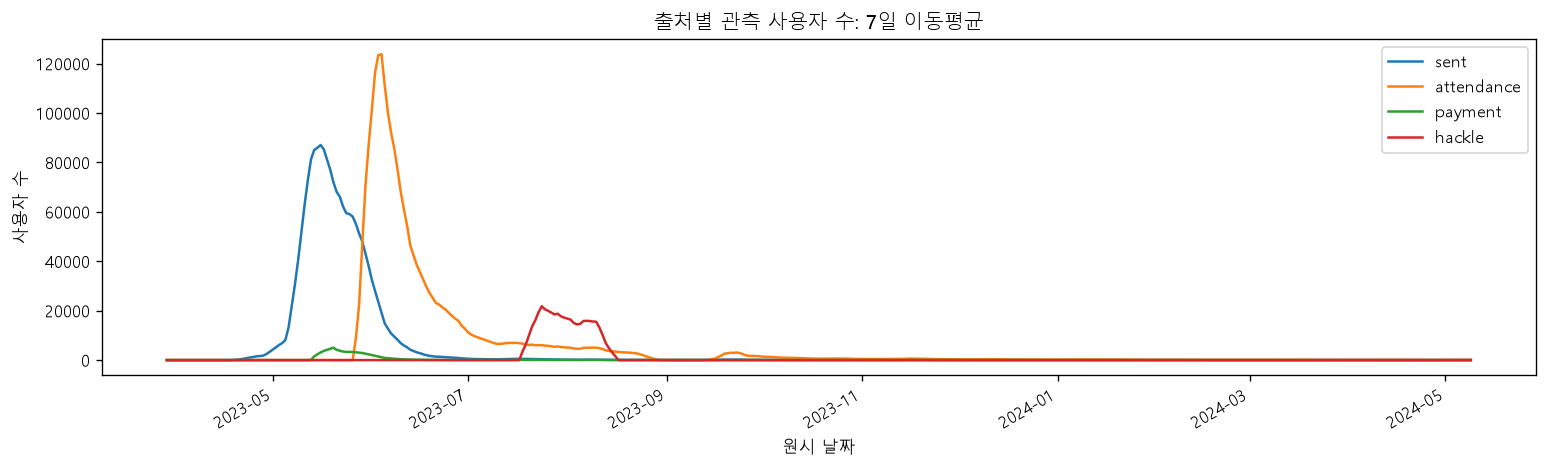

,source,start,end,days
3,attendance,2023-08-28,2023-09-11,15
60,question,2024-04-01,2024-04-11,11
59,question,2024-03-20,2024-03-29,10
65,question,2024-04-23,2024-05-02,10
54,question,2024-02-10,2024-02-18,9
58,question,2024-03-11,2024-03-16,6
55,question,2024-02-21,2024-02-26,6
13,payment,2024-03-03,2024-03-07,5
57,question,2024-03-04,2024-03-07,4
38,question,2023-11-24,2023-11-27,4


**판독:** 출처별 기록이 없는 기간을 확인했다. 특히 출석 공백은 기능 중단과 수집 누락을 이 데이터만으로 구분할 수 없다. Hackle 구간의 관측 증가를 서비스 회복으로 해석하지 않는다.

In [3]:
fig,ax=plt.subplots(figsize=(13,4))
daily[['sent','attendance','payment','hackle']].rolling(7,min_periods=1).mean().plot(ax=ax)
ax.set(title='출처별 관측 사용자 수: 7일 이동평균',ylabel='사용자 수',xlabel='원시 날짜')
plt.tight_layout();plt.show()
calendar=pd.date_range(daily.index.min(),daily.index.max())
gap_rows=[]
for col in ['sent','attendance','payment','question','hackle']:
    series=daily[col].reindex(calendar,fill_value=0)
    nonzero=series[series.gt(0)]
    zero=series.loc[nonzero.index.min():nonzero.index.max()].eq(0)
    for _,g in zero.groupby(zero.ne(zero.shift()).cumsum()):
        if g.iloc[0]: gap_rows.append({'source':col,'start':g.index.min(),'end':g.index.max(),'days':len(g)})
gaps=pd.DataFrame(gap_rows,columns=['source','start','end','days'])
display(save(gaps,'03_internal_zero_days').sort_values('days',ascending=False).head(20))
show('**판독:** 출처별 기록이 없는 기간을 확인했다. 특히 출석 공백은 기능 중단과 수집 누락을 이 데이터만으로 구분할 수 없다. Hackle 구간의 관측 증가를 서비스 회복으로 해석하지 않는다.')

## 2. 5월 가입 코호트: 얼마나 후속 활동이 관측되는가

먼저 **5월 전체 가입자**에게 관측 범위를 맞출 수 있는 친구요청 발송만 제시한다. 다음 복합 핵심 DB 지표는 친구요청 발송 또는 결제 성공이다. 두 출처 외곽 범위의 교집합에서 가입 이후 전체 기간이 확보된 사용자를 분모로 삼으므로 **5월 중 일부 가입일 코호트만 남을 수 있다**. 결제의 외곽 범위는 포인트와 합친 flag 대신 실제 결제 기록일로 더 보수적으로 제한한다. 결제 첫 발생 이전에 수집 자체가 없었는지는 확정할 수 없으므로, 이것은 분석의 보수적 선택이다.

`D8~D30`, `D31~D90`, `D91~D180`은 길이가 다르므로 서로의 비율 차이를 리텐션 감소 속도로 읽지 않는다. 별도로 같은 길이인 가입 후 주차별 활동률을 제시한다. 출석 포함 비율은 다른 행동 정의에 대한 민감도 분석이며 핵심 활동률과 평균내지 않는다.

,group,n,active,rate,ci_low,ci_high
0,D8~D30,635505,174365,0.2744,0.2733,0.2755
1,D31~D90,635505,19727,0.0310,0.0306,0.0315
2,D91~D180,635505,3604,0.0057,0.0055,0.0059


**분모 구분:** 5월 비직원 가입자는 635,505명이다. 복합 지표의 보수적 공통 범위는 2023-05-13~2024-05-08이며, D0~D30 비교 대상은 336,194명이다. 이전 가입자 299,311명은 결제 관측 범위 확정이 어려워 복합 비교에서 제외된다. 전체 5월 결과는 위 친구요청 발송 표를 사용한다.

,group,n,active,rate,ci_low,ci_high,kind,mean_days,median_days_active,repeat_2days_rate
0,D8~D30,336194,81917,0.2437,0.2422,0.2451,core,0.4195,1.0000,0.0947
1,D8~D30,336194,180159,0.5359,0.5342,0.5376,extended,2.7685,3.0000,0.3998
2,D31~D90,336194,8509,0.0253,0.0248,0.0258,core,0.0322,1.0000,0.0042
3,D31~D90,336194,56123,0.1669,0.1657,0.1682,extended,0.7186,2.0000,0.0904
4,D91~D180,336194,2100,0.0062,0.0060,0.0065,core,0.0071,1.0000,0.0006
5,D91~D180,336194,16166,0.0481,0.0474,0.0488,extended,0.1276,1.0000,0.0177
6,D181~D270,336194,699,0.0021,0.0019,0.0022,core,0.0022,1.0000,0.0001
7,D181~D270,336194,4743,0.0141,0.0137,0.0145,extended,0.0347,1.0000,0.0033
8,D271~D360,76854,41,0.0005,0.0004,0.0007,core,0.0006,1.0000,0.0000
9,D271~D360,76854,312,0.0041,0.0036,0.0045,extended,0.0064,1.0000,0.0007


,group,n,active,rate,ci_low,ci_high
0,2023-05,336194,81917,0.2437,0.2422,0.2451
1,2023-06,16737,1920,0.1147,0.1100,0.1196
2,2023-07,1849,112,0.0606,0.0506,0.0724
3,2023-08,524,18,0.0344,0.0218,0.0536
4,2023-09,602,31,0.0515,0.0365,0.0722
5,2023-10,409,13,0.0318,0.0187,0.0536
6,2023-11,731,5,0.0068,0.0029,0.0159
7,2023-12,231,5,0.0216,0.0093,0.0497
8,2024-01,455,6,0.0132,0.0061,0.0285
9,2024-02,255,5,0.0196,0.0084,0.0451


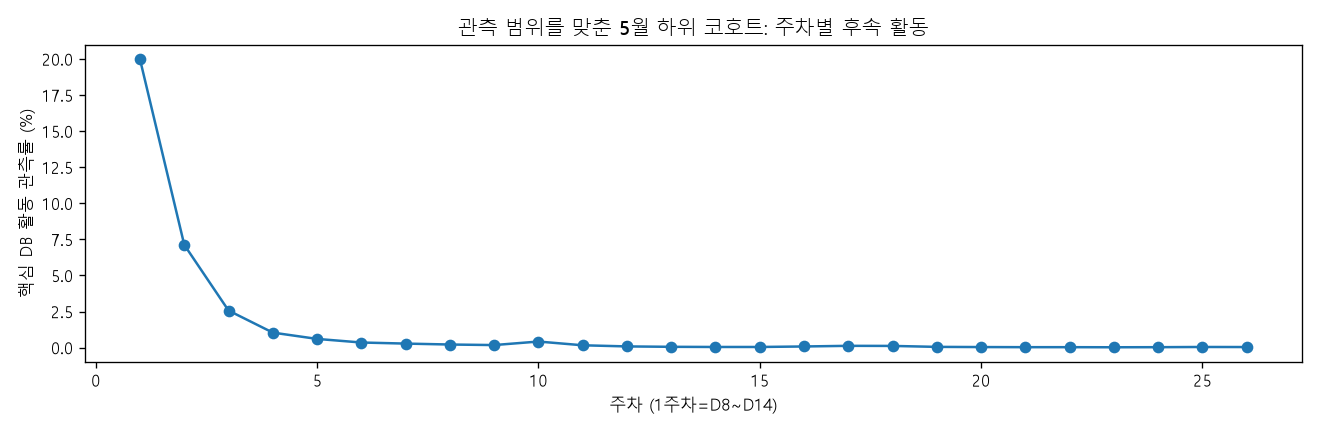

**결과:** 관측 범위를 맞춘 5월 가입자 하위 코호트 336,194명 중 D8~D30 핵심 DB 활동은 81,917명(24.37%)에서 관측됐다. 전체 5월 가입자의 앱 재방문율로 해석하지 않는다.

In [4]:
core_start=max(coverage.loc['friend_request_source_range_flag','start'],a.loc[a.payment,'date'].min())
core_end=min(coverage.loc['friend_request_source_range_flag','end'],a.loc[a.payment,'date'].max())
def eligible(base,lo,hi,start=core_start,end=core_end):
    return base[(base.signup_date+pd.Timedelta(days=lo)>=start)&(base.signup_date+pd.Timedelta(days=hi)<=end)].copy()
may=users[users.cohort.eq('2023-05')].copy()
def attach_days(base,lo,hi,kind):
    d=a[a.age.between(lo,hi)&a[kind]].groupby('user_id').size()
    return base.index.to_series().map(d).fillna(0).astype(int)
friend_start=coverage.loc['friend_request_source_range_flag','start']
friend_end=coverage.loc['friend_request_source_range_flag','end']
allmay=[]
for lo,hi in [(8,30),(31,90),(91,180)]:
    bb=eligible(may,0,hi,friend_start,friend_end)
    rr=rate_row(f'D{lo}~D{hi}',attach_days(bb,lo,hi,'sent').gt(0));allmay.append(rr)
fullmay=save(pd.DataFrame(allmay),'04a_full_may_friend_sent_followup')
display(fullmay)
show(f'**분모 구분:** 5월 비직원 가입자는 {len(may):,}명이다. 복합 지표의 보수적 공통 범위는 {core_start.date()}~{core_end.date()}이며, D0~D30 비교 대상은 {len(eligible(may,0,30)):,}명이다. 이전 가입자 {len(may)-len(eligible(may,0,30)):,}명은 결제 관측 범위 확정이 어려워 복합 비교에서 제외된다. 전체 5월 결과는 위 친구요청 발송 표를 사용한다.')
summary=[]
for lo,hi in [(8,30),(31,90),(91,180),(181,270),(271,360)]:
    base=eligible(may,0,hi)
    for kind in ['core','extended']:
        days=attach_days(base,lo,hi,kind)
        row=rate_row(f'D{lo}~D{hi}',days.gt(0));row.update(kind=kind,mean_days=days.mean(),
            median_days_active=days[days.gt(0)].median(),repeat_2days_rate=days.ge(2).mean())
        summary.append(row)
db_summary=save(pd.DataFrame(summary),'04_may_followup')
display(db_summary)
coh=[]
for month,base in users.groupby('cohort'):
    b=eligible(base,0,30)
    if len(b): coh.append(rate_row(month,attach_days(b,8,30,'core').gt(0)))
cohort_result=save(pd.DataFrame(coh),'05_monthly_cohort_d8_d30')
display(cohort_result)
weekly=[]
for w in range(1,27):
    lo=7*w+1;hi=lo+6;b=eligible(may,0,hi)
    row=rate_row(w,attach_days(b,lo,hi,'core').gt(0));weekly.append(row)
weekly=pd.DataFrame(weekly)
save(weekly,'06_may_equal_week_activity')
fig,ax=plt.subplots(figsize=(11,3.6));ax.plot(weekly.group,100*weekly.rate,marker='o')
ax.set(xlabel='주차 (1주차=D8~D14)',ylabel='핵심 DB 활동 관측률 (%)',title='관측 범위를 맞춘 5월 하위 코호트: 주차별 후속 활동')
plt.tight_layout();plt.show()
r=db_summary[(db_summary.group=='D8~D30')&(db_summary.kind=='core')].iloc[0]
show(f'**결과:** 관측 범위를 맞춘 5월 가입자 하위 코호트 {r.n:,.0f}명 중 D8~D30 핵심 DB 활동은 {r.active:,.0f}명({r.rate:.2%})에서 관측됐다. 전체 5월 가입자의 앱 재방문율로 해석하지 않는다.')

## 3. 초기 경험과 이후 활동을 연결한다

설명 변수는 D0~D7, 결과는 D8~D30으로 분리한다. ‘친구요청 수신’은 관계를 수락하거나 관계가 형성되었다는 의미가 아니다. 질문 생성·투표·Ping 수신 비교는 질문 소유자의 현재 학교로 추정한 제공 범위에 제한한다. 학교 이동 이력이 없으므로 이는 현재 소속 기준 범위다.

비교마다 표본 수와 95% Wilson 구간을 표시한다. 이 구간은 개인 독립 가정의 기술적 불확실성이며 학교 내 상관을 보정한 인과 추론용 구간이 아니다. 사용자 활동 성향 차이를 줄이기 위해 가입 주·초기 활동일 구간별 공통 가중 표준화도 함께 본다. 각 층에서 양쪽 그룹이 20명 이상인 공통 지지 영역만 사용하고 남은 표본 비율을 공개한다.

In [5]:
sets=read('mart_question_set_record_v2',['question_set_owner_user_id','question_set_created_at','owner_current_school_id'])
schools=sets.owner_current_school_id.dropna().unique()
q_start=pd.to_datetime(sets.question_set_created_at,format='mixed').min().ceil('D')
q_end=pd.to_datetime(sets.question_set_created_at,format='mixed').max().floor('D')-pd.Timedelta(days=1)
show(f'질문 데이터 소유자의 현재 학교: **{len(schools)}개**. 범위는 {q_start.date()}~{q_end.date()}의 완전한 내부 날짜를 사용한다.')
base=eligible(may,0,30)
base['later']=attach_days(base,8,30,'core').gt(0)
base['early_days']=attach_days(base,0,7,'core')
base['activity_band']=pd.cut(base.early_days,[-1,0,1,3,8],labels=['0','1','2~3','4~8']).astype(str)
for feature in ['sent','received','payment','question','vote','ping_received']:
    ids=a.loc[a.age.between(0,7)&a[feature],'user_id'].unique()
    base[feature]=base.index.isin(ids)
# 부정 경험은 정확한 사건 시각이 있는 행의 행위자에 한정한다.
s=read('mart_safety_event_v2',['source_table','source_row_id','actor_user_id','event_at_raw','is_true_event_time_flag','canonical_semantic_record_flag','feedback_domain_rule_v1'])
s=s[s.is_true_event_time_flag.eq(1)&s.canonical_semantic_record_flag.eq(1)].copy()
s['date']=pd.to_datetime(s.event_at_raw,format='mixed',errors='coerce').dt.normalize()
s['age']=(s.date-s.actor_user_id.map(users.signup_date)).dt.days
base['feedback']=base.index.isin(s.loc[s.age.between(0,7),'actor_user_id'])
display(save(s.groupby(['source_table','feedback_domain_rule_v1']).agg(rows=('source_row_id','size'),start=('date','min'),end=('date','max')).reset_index(),'07_safety_scope'))
comparisons=[];adjusted=[]
def compare(b,feature,label,outcome='later',strata=['signup_week','activity_band']):
    for value,g in b.groupby(feature):
        row=rate_row(label+' / '+str(bool(value)),g[outcome]);row.update(feature=feature,outcome=outcome)
        comparisons.append(row)
    t=b.groupby(strata+[feature],observed=True)[outcome].agg(['size','mean']).unstack(feature)
    if not all(v in t['size'].columns for v in [False,True]):
        adjusted.append(dict(feature=feature,label=label,outcome=outcome,common_n=0,total_n=len(b),retained=0,unexposed_rate=np.nan,exposed_rate=np.nan,difference_pp=np.nan,strata=0,status='비교군 한쪽 부재'))
        return
    ok=t['size'].fillna(0).min(axis=1).ge(20)
    t=t.loc[ok]; n=t['size'].sum().sum()
    if n:
        weight=t['size'].sum(axis=1)/n
        p0=(t['mean'][False]*weight).sum();p1=(t['mean'][True]*weight).sum()
        adjusted.append(dict(feature=feature,label=label,outcome=outcome,common_n=int(n),total_n=len(b),
                             retained=n/len(b),unexposed_rate=p0,exposed_rate=p1,difference_pp=100*(p1-p0),strata=len(t),status='제한적 공통지지' if n/len(b)<.5 else '공통지지 비교'))
    else:
        adjusted.append(dict(feature=feature,label=label,outcome=outcome,common_n=0,total_n=len(b),retained=0,unexposed_rate=np.nan,exposed_rate=np.nan,difference_pp=np.nan,strata=0,status='양군 20명 이상 공통층 없음'))
for feature,label in [('sent','초기 친구요청 발송'),('received','초기 친구요청 수신'),('payment','초기 결제 성공'),('feedback','초기 피드백·신고 작성')]:
    compare(base,feature,label)
qbase=eligible(may[may.current_school_id.isin(schools)],0,30,q_start,q_end)
for feature in ['question','vote','ping_received']:
    qbase[feature]=qbase.index.isin(a.loc[a.age.between(0,7)&a[feature],'user_id'])
qbase['question_later']=attach_days(qbase,8,30,'question_active').gt(0)
qbase['activity_band']=pd.cut(attach_days(qbase,0,7,'question_active'),[-1,0,1,3,8],labels=['0','1','2~3','4~8']).astype(str)
for feature,label in [('question','10개교 초기 질문 생성'),('vote','10개교 초기 투표 기록'),('ping_received','10개교 초기 Ping 수신')]:
    compare(qbase,feature,label,'question_later')
comparison=save(pd.DataFrame(comparisons),'08_initial_experience_raw')
adjustment=save(pd.DataFrame(adjusted),'09_initial_experience_standardized')
display(comparison);display(adjustment)
show(f'**표본 범위:** 전국 복합 지표 비교 {len(base):,}명, 질문 범위 비교 {len(qbase):,}명. 질문 비교에는 결제 시작일 제한을 적용하지 않았다.')
show('**해석:** 원시 차이와 층화 후 차이가 같은 방향인지 확인한다. 층화 후에도 남는 차이는 연관성이며 효과가 아니다. 활동이 적으면 신고할 기회도 적으므로 피드백 작성자의 높은 잔존을 부정 경험의 이점으로 해석하지 않는다. 수락·Ping 열람의 과거 시점은 확정할 수 없어 DB 초기 경험 비교에서 제외했다.')

질문 데이터 소유자의 현재 학교: **10개**. 범위는 2023-04-29~2024-05-06의 완전한 내부 날짜를 사용한다.

,source_table,feedback_domain_rule_v1,rows,start,end
0,accounts_blockrecord,ACCOUNT_INTEGRITY,2022,2023-05-06,2024-04-05
1,accounts_blockrecord,OTHER,13,2023-05-04,2023-05-05
2,accounts_blockrecord,RELATIONSHIP_FREQUENCY,919,2023-05-06,2024-02-28
3,accounts_blockrecord,RELATIONSHIP_MISMATCH,15440,2023-05-05,2024-05-06
4,accounts_blockrecord,RELATIONSHIP_RELEVANCE,1083,2023-05-05,2024-02-15
5,accounts_timelinereport,ACCOUNT_INTEGRITY,15,2023-05-06,2023-05-22
6,accounts_timelinereport,CONTENT_SAFETY,39,2023-05-06,2023-06-01
7,accounts_timelinereport,HARASSMENT,64,2023-05-06,2023-06-02
8,accounts_timelinereport,MISINFORMATION,80,2023-05-06,2023-05-31
9,accounts_timelinereport,SPAM,10,2023-05-10,2023-05-22


,group,n,active,rate,ci_low,ci_high,feature,outcome
0,초기 친구요청 발송 / False,17892,3253,0.1818,0.1762,0.1875,sent,later
1,초기 친구요청 발송 / True,318302,78664,0.2471,0.2456,0.2486,sent,later
2,초기 친구요청 수신 / False,14181,1677,0.1183,0.1130,0.1237,received,later
3,초기 친구요청 수신 / True,322013,80240,0.2492,0.2477,0.2507,received,later
4,초기 결제 성공 / False,305224,73278,0.2401,0.2386,0.2416,payment,later
5,초기 결제 성공 / True,30970,8639,0.2789,0.2740,0.2840,payment,later
6,초기 피드백·신고 작성 / False,324934,78656,0.2421,0.2406,0.2435,feedback,later
7,초기 피드백·신고 작성 / True,11260,3261,0.2896,0.2813,0.2981,feedback,later
8,10개교 초기 질문 생성 / False,137,34,0.2482,0.1834,0.3267,question,question_later
9,10개교 초기 질문 생성 / True,4495,3308,0.7359,0.7228,0.7486,question,question_later


,feature,label,outcome,common_n,total_n,retained,unexposed_rate,exposed_rate,difference_pp,strata,status
0,sent,초기 친구요청 발송,later,112408,336194,0.3344,0.2195,0.1509,-6.8604,3,제한적 공통지지
1,received,초기 친구요청 수신,later,320970,336194,0.9547,0.2080,0.2320,2.4010,15,공통지지 비교
2,payment,초기 결제 성공,later,318580,336194,0.9476,0.2500,0.2297,-2.0333,12,공통지지 비교
3,feedback,초기 피드백·신고 작성,later,327686,336194,0.9747,0.2457,0.2452,-0.0499,13,공통지지 비교
4,question,10개교 초기 질문 생성,question_later,0,4632,0.0000,NaN,NaN,NaN,0,양군 20명 이상 공통층 없음
5,vote,10개교 초기 투표 기록,question_later,237,4632,0.0512,0.1698,0.3136,14.3860,3,제한적 공통지지
6,ping_received,10개교 초기 Ping 수신,question_later,54,4632,0.0117,0.6190,0.1212,-49.7835,1,제한적 공통지지


**표본 범위:** 전국 복합 지표 비교 336,194명, 질문 범위 비교 4,632명. 질문 비교에는 결제 시작일 제한을 적용하지 않았다.

**해석:** 원시 차이와 층화 후 차이가 같은 방향인지 확인한다. 층화 후에도 남는 차이는 연관성이며 효과가 아니다. 활동이 적으면 신고할 기회도 적으므로 피드백 작성자의 높은 잔존을 부정 경험의 이점으로 해석하지 않는다. 수락·Ping 열람의 과거 시점은 확정할 수 없어 DB 초기 경험 비교에서 제외했다.

## 4. 일회성 복귀와 반복 활동, 긴 공백을 구분한다

핵심 DB 활동이 D8~D30에 한 번이라도 있었다는 것만으로 반복 사용을 주장하지 않는다. 활동일 수·활동 주 수를 추가한다. 공백은 **해당 DB 행동이 기록되지 않은 달력일 수**다. `14일 공백`은 두 기록 간 날짜 차이가 15일 이상인 경우를 뜻한다.

첫 공백 분석은 D0~D7 핵심 활동자만 대상으로 한다. 마지막 활동 뒤 관측 종료가 가까우면 공백 여부를 판단할 수 없는 우측 검열로 남긴다. D90까지 활동을 다시 관측하지 못한 경우도 영구 이탈로 해석하지 않는다.

In [6]:
b=eligible(may,0,90)
d=a[a.user_id.isin(b.index)&a.age.between(8,30)&a.core].copy()
d['week']=(d.age-8)//7
rep=b[['cohort']].copy()
rep['days']=d.groupby('user_id').size().reindex(rep.index,fill_value=0)
rep['weeks']=d.groupby('user_id').week.nunique().reindex(rep.index,fill_value=0)
rep['pattern']=np.select([rep.days.eq(0),rep.days.eq(1),rep.weeks.eq(1)],['미관측','하루만 관측','한 주 내 반복'],default='여러 주 반복')
repeat=rep.groupby('pattern').agg(users=('cohort','size'),mean_days=('days','mean'),mean_weeks=('weeks','mean')).reset_index()
repeat['share']=repeat.users/len(rep);display(save(repeat,'10_repeat_patterns'))
early_ids=a.loc[a.user_id.isin(b.index)&a.age.between(0,7)&a.core,'user_id'].unique()
e=a[a.user_id.isin(early_ids)&a.age.between(0,90)&a.core][['user_id','age']].sort_values(['user_id','age']).copy()
e['next_age']=e.groupby('user_id').age.shift(-1)
gap_results=[]
for threshold in [7,14,30]:
    z=e.copy();z['complete_gap']=(z.next_age-z.age-1).ge(threshold)
    z['terminal_gap']=z.next_age.isna() & (90-z.age).ge(threshold)
    first=z[z.complete_gap|z.terminal_gap].drop_duplicates('user_id')
    row={'no_record_days':threshold,'early_active_users':len(early_ids),'first_gap_users':len(first),
         'returned_by_d90':int(first.complete_gap.sum()),'no_return_by_d90':int(first.terminal_gap.sum()),
         'no_observed_complete_gap':len(early_ids)-len(first)}
    no_gap_ids=set(early_ids)-set(first.user_id)
    terminal=z[z.user_id.isin(no_gap_ids)&z.next_age.isna()]
    row['right_censored_before_gap_threshold']=int((90-terminal.age).lt(threshold).sum())
    row['return_given_gap']=row['returned_by_d90']/len(first) if len(first) else np.nan
    row['median_first_gap_start_day']=(first.age+1).median()
    gap_results.append(row)
display(save(pd.DataFrame(gap_results),'11_first_gap_and_return'))
# 후기 행동 구성은 동일 코호트의 23일 구간을 비교한다. 양쪽 기간 활동자 수가 다르다.
beh=[]
for lo,hi in [(8,30),(68,90)]:
    d=a[a.user_id.isin(b.index)&a.age.between(lo,hi)]
    active=d.loc[d.core,'user_id'].nunique()
    for kind in ['sent','payment','attendance']:
        ids=set(d.loc[d[kind],'user_id']) & set(d.loc[d.core,'user_id'])
        beh.append({'window':f'D{lo}~D{hi}','behavior':kind,'core_active_users':active,'behavior_users':len(ids),'share':len(ids)/active if active else np.nan})
display(save(pd.DataFrame(beh),'12_later_behavior_composition'))
show('**해석:** 후기 구성은 그때 관측된 사용자에 대한 조건부 분포다. 초기 전체 사용자가 같은 행동으로 전환했다는 증거가 아니며 생존자 선택이 있다. 출석은 핵심 활동자 안에서의 동시 관측만 제시한다.')

,pattern,users,mean_days,mean_weeks,share
0,미관측,254277,0.0000,0.0000,0.7563
1,여러 주 반복,16691,3.2722,2.1476,0.0496
2,하루만 관측,50078,1.0000,1.0000,0.1490
3,한 주 내 반복,15148,2.3987,1.0000,0.0451


,no_record_days,early_active_users,first_gap_users,returned_by_d90,no_return_by_d90,no_observed_complete_gap,right_censored_before_gap_threshold,return_given_gap,median_first_gap_start_day
0,7,318580,318580,46678,271902,0,0,0.1465,3.0000
1,14,318580,318578,16297,302281,2,2,0.0512,3.0000
2,30,318580,318460,4889,313571,120,120,0.0154,4.0000


,window,behavior,core_active_users,behavior_users,share
0,D8~D30,sent,81917,78841,0.9624
1,D8~D30,payment,81917,6149,0.0751
2,D8~D30,attendance,81917,55521,0.6778
3,D68~D90,sent,2356,1458,0.6188
4,D68~D90,payment,2356,933,0.3960
5,D68~D90,attendance,2356,1295,0.5497


**해석:** 후기 구성은 그때 관측된 사용자에 대한 조건부 분포다. 초기 전체 사용자가 같은 행동으로 전환했다는 증거가 아니며 생존자 선택이 있다. 출석은 핵심 활동자 안에서의 동시 관측만 제시한다.

## 5. Hackle: 첫 관측 이후 D1·D3·D7 재방문

관측기간 내 첫 **활동일**을 기준으로 해당 날짜에 다시 기록되었는지 계산한다(정확한 N일 후 재방문). D1~D7 중 아무 날의 재방문은 별도 지표다. 개인마다 관측 종료까지 확보한 기간으로 분모를 제한한다.

일별 마트의 `hackle_visit_count`는 자정을 걸친 방문이 중복 반영될 수 있으므로 총 방문 수는 방문 마트의 고유 30분 세션 ID로 센다. 사용자 간 비교는 모두 D0~D7로 기간을 맞춘다. 첫 관측이 7월 18일인 사용자는 이미 활동하던 사용자일 수 있으므로 이들을 제외한 민감도 결과도 제시한다.

,field,total_events,positive_user_days
0,hackle_question_start_count,170320,105100
1,hackle_question_complete_count,123899,77952
2,hackle_ping_open_count,0,0
3,hackle_shop_event_count,26620,13002


**측정 제한 발견:** 제공된 Hackle 일별 마트의 Ping 열람은 전부 0이다. 이를 실제 미열람으로 해석할 수 없으며 Ping 열람 경험과 재방문의 비교는 계산 불가로 표시한다. 이벤트 매핑·원천 계측 검증이 필요하다.

,group,n,active,rate,ci_low,ci_high
0,전체 D1,139466,25402,0.1821,0.1801,0.1842
1,전체 D3,136945,18878,0.1379,0.1360,0.1397
2,전체 D7,117408,14274,0.1216,0.1197,0.1235
3,7월18일 첫관측 제외 D1,115121,16735,0.1454,0.1433,0.1474
4,7월18일 첫관측 제외 D3,112600,10692,0.0950,0.0933,0.0967
5,7월18일 첫관측 제외 D7,93063,8187,0.0880,0.0862,0.0898


raw_daily_rows                    418114
excluded_unknown_or_staff_rows         0
pre_signup_rows                       43
dtype: int64

,age_group,users,return_1_7,return_d7,mean_active_days
0,가입 당일,505,0.6396,0.3050,3.5703
1,가입 1~7일,691,0.8784,0.5109,5.4023
2,가입 8~30일,404,0.7228,0.3094,3.4505
3,가입 31일+,115808,0.4558,0.1178,1.9965


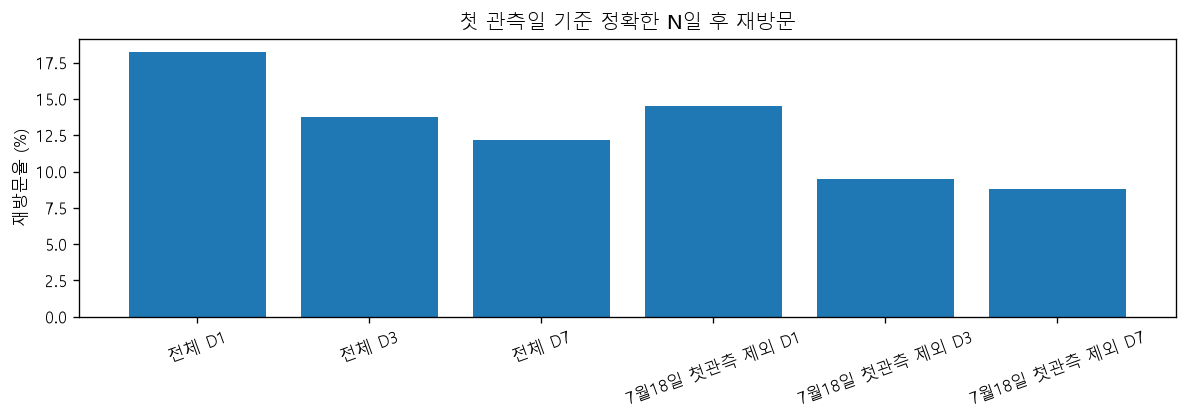

In [7]:
h=read('mart_hackle_user_daily_24d_v2')
h['date']=pd.to_datetime(h.activity_date)
HSTART=pd.Timestamp('2023-07-18');HEND=pd.Timestamp('2023-08-10')
haudit={'raw_daily_rows':len(h),'excluded_unknown_or_staff_rows':int((~h.user_id.isin(users.index)).sum())}
h=h[h.user_id.isin(users.index)&h.date.between(HSTART,HEND)].copy()
haudit['pre_signup_rows']=int((h.date<h.user_id.map(users.signup_date)).sum())
h=h[h.date.ge(h.user_id.map(users.signup_date)) & h.hackle_event_count.gt(0)]
assert not h.duplicated(['user_id','date']).any()
hackle_fields=pd.DataFrame([{'field':col,'total_events':h[col].sum(),'positive_user_days':h[col].gt(0).sum()} for col in ['hackle_question_start_count','hackle_question_complete_count','hackle_ping_open_count','hackle_shop_event_count']])
display(save(hackle_fields,'13_hackle_field_availability'))
if h.hackle_ping_open_count.sum()==0:
    show('**측정 제한 발견:** 제공된 Hackle 일별 마트의 Ping 열람은 전부 0이다. 이를 실제 미열람으로 해석할 수 없으며 Ping 열람 경험과 재방문의 비교는 계산 불가로 표시한다. 이벤트 매핑·원천 계측 검증이 필요하다.')
first=h.groupby('user_id').date.min()
h['day']=(h.date-h.user_id.map(first)).dt.days
hb=users.loc[first.index].copy();hb['first']=first
hb['first_boundary']=hb['first'].eq(HSTART)
hb['signup_age_at_first']=(hb['first']-hb.signup_date).dt.days
rows=[]
for label,mask in [('전체',pd.Series(True,index=hb.index)),('7월18일 첫관측 제외',~hb.first_boundary)]:
    for day in [1,3,7]:
        b=hb[mask & (hb['first']+pd.Timedelta(days=day)<=HEND)]
        yes=h.loc[h.day.eq(day),'user_id'].unique()
        row=rate_row(label+f' D{day}',pd.Series(b.index.isin(yes)));rows.append(row)
hr=save(pd.DataFrame(rows),'13_hackle_exact_day_return')
display(hr);display(pd.Series(haudit))
hb=hb[hb['first']+pd.Timedelta(days=7)<=HEND].copy()
hb['return_1_7']=hb.index.isin(h.loc[h.day.between(1,7),'user_id'])
hb['return_d7']=hb.index.isin(h.loc[h.day.eq(7),'user_id'])
hb['days_0_7']=h[h.day.between(0,7)].groupby('user_id').size().reindex(hb.index,fill_value=0)
hb['age_group']=pd.cut(hb.signup_age_at_first,[-1,0,7,30,np.inf],labels=['가입 당일','가입 1~7일','가입 8~30일','가입 31일+'])
display(save(hb.groupby('age_group',observed=True).agg(users=('first','size'),return_1_7=('return_1_7','mean'),return_d7=('return_d7','mean'),mean_active_days=('days_0_7','mean')).reset_index(),'14_hackle_signup_age'))
fig,ax=plt.subplots(figsize=(10,3.6));ax.bar(hr.group,100*hr.rate)
ax.set(ylabel='재방문율 (%)',title='첫 관측일 기준 정확한 N일 후 재방문');ax.tick_params(axis='x',rotation=20)
plt.tight_layout();plt.show()

## 6. 첫 관측 경험과 재방문의 관계, 재방문 시 행동

첫 관측일의 질문 완료·Ping 열람을 초기 경험으로 정하고 D1~D7 재방문을 비교한다. ‘결과 확인’은 별도 필드가 없어 Ping 열람으로 대체했다고 주장하지 않는다. 첫날 완료는 같은 날 시작 이벤트와의 순서를 보장하지 않으므로 퍼널 전환율로 표현하지 않는다.

가입 경과 구간·첫 관측 날짜·첫날 이벤트 수 구간을 맞춘 표준화를 추가한다. 전체 관측기간 이벤트 합을 초기 경험으로 사용하지 않는다. 첫 방문과 재방문 비교는 **동일 재방문자**의 첫 관측일과 두 번째 활동일을 짝지어 비교한다.

,group,n,active,rate,ci_low,ci_high,feature,outcome
0,Hackle 첫 관측일 question_complete / False,101408,44165,0.4355,0.4325,0.4386,question_complete,return_1_7
1,Hackle 첫 관측일 question_complete / True,16000,9837,0.6148,0.6072,0.6223,question_complete,return_1_7
2,Hackle 첫 관측일 ping_open / False,117408,54002,0.4600,0.4571,0.4628,ping_open,return_1_7
3,Hackle 첫 관측일 question_start / False,92851,40653,0.4378,0.4346,0.4410,question_start,return_1_7
4,Hackle 첫 관측일 question_start / True,24557,13349,0.5436,0.5374,0.5498,question_start,return_1_7


,feature,label,outcome,common_n,total_n,retained,unexposed_rate,exposed_rate,difference_pp,strata,status
0,question_complete,Hackle 첫 관측일 question_complete,return_1_7,93111,117408,0.7931,0.4131,0.5373,12.4223,53,공통지지 비교
1,ping_open,Hackle 첫 관측일 ping_open,return_1_7,0,117408,0.0000,NaN,NaN,NaN,0,비교군 한쪽 부재
2,question_start,Hackle 첫 관측일 question_start,return_1_7,101198,117408,0.8619,0.4246,0.4697,4.5127,56,공통지지 비교


**교차 확인:** 방문 마트 전체의 Ping 열람 이벤트 합계도 0건이다. 원천 이벤트를 확인하기 전에는 열람 행동에 관한 제품 결론을 보류한다.

all_visits                   896009
unmatched_or_staff_visits    269022
conflict_visits              228101
dtype: int64

,days_0_7,visits_0_7
count,"117,408.0000","117,408.0000"
mean,2.0283,3.0305
std,1.6024,5.4692
min,1.0000,1.0000
25%,1.0000,1.0000
50%,1.0000,2.0000
75%,2.0000,3.0000
max,8.0000,126.0000


,stat,gap_hours
0,count,"238,376.0000"
1,mean,24.7238
2,std,35.2567
3,min,0.0006
4,25%,2.2242
5,50%,10.1536
6,75%,28.6468
7,90%,73.0540
8,max,191.4428


,behavior,day_order,paired_users,observed_rate,mean_count
0,hackle_question_start_count,1,54002,0.2472,0.3904
1,hackle_question_start_count,2,54002,0.2418,0.3893
2,hackle_question_complete_count,1,54002,0.1822,0.2767
3,hackle_question_complete_count,2,54002,0.1824,0.2851
4,hackle_ping_open_count,1,54002,0.0000,0.0000
5,hackle_ping_open_count,2,54002,0.0000,0.0000
6,hackle_shop_event_count,1,54002,0.0415,0.0948
7,hackle_shop_event_count,2,54002,0.0333,0.0704


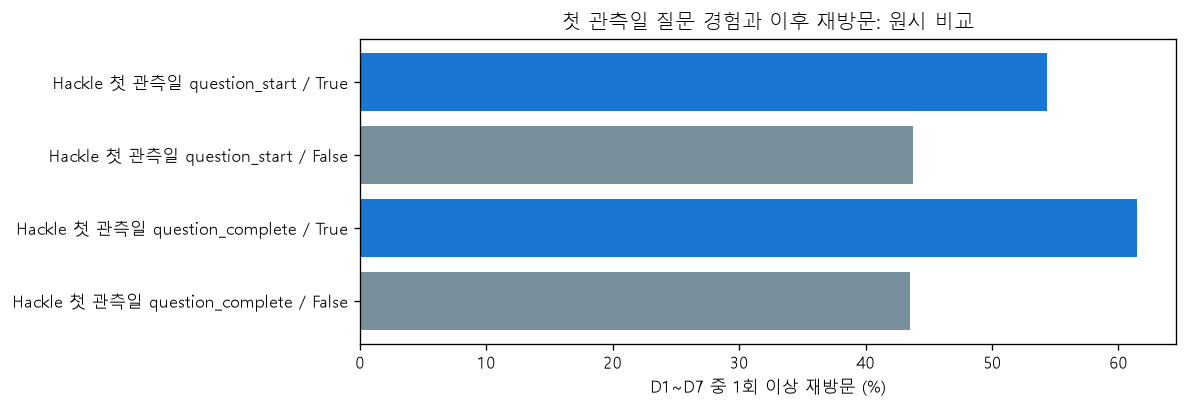

**판독:** 방문 간격은 7일 안에 다시 관측된 방문 사이의 조건부 분포다. 돌아오지 않은 사용자의 대기시간은 포함되지 않는다. 첫날/둘째 활동일의 차이는 하루당 이용 시간 차이도 반영하며 경험의 개선 효과를 뜻하지 않는다.

In [8]:
firstday=h[h.day.eq(0)].set_index('user_id')
hb['question_complete']=firstday.hackle_question_complete_count.reindex(hb.index).gt(0)
hb['ping_open']=firstday.hackle_ping_open_count.reindex(hb.index).gt(0)
hb['question_start']=firstday.hackle_question_start_count.reindex(hb.index).gt(0)
hb['first_date']=hb['first'].astype(str)
hb['event_band']=pd.cut(firstday.hackle_event_count.reindex(hb.index),[0,3,10,30,np.inf],labels=['1~3','4~10','11~30','31+']).astype(str)
comparisons=[];adjusted=[]
for feature in ['question_complete','ping_open','question_start']:
    compare(hb,feature,'Hackle 첫 관측일 '+feature,'return_1_7',['first_date','age_group','event_band'])
hcompare=save(pd.DataFrame(comparisons),'15_hackle_first_experience_raw')
hadjust=save(pd.DataFrame(adjusted),'16_hackle_first_experience_standardized')
display(hcompare);display(hadjust)
vis=read('mart_hackle_visit_30m_v2',['analytics_visit_session_id','service_user_id','visit_start_at_30m','visit_end_at_30m','user_conflict_flag','ping_open_count'])
show(f'**교차 확인:** 방문 마트 전체의 Ping 열람 이벤트 합계도 {vis.ping_open_count.sum():,.0f}건이다. 원천 이벤트를 확인하기 전에는 열람 행동에 관한 제품 결론을 보류한다.')
assert vis.analytics_visit_session_id.is_unique
vis['start']=pd.to_datetime(vis.visit_start_at_30m,format='mixed',errors='coerce')
vis['end']=pd.to_datetime(vis.visit_end_at_30m,format='mixed',errors='coerce')
visit_audit={'all_visits':len(vis),'unmatched_or_staff_visits':int((~vis.service_user_id.isin(users.index)).sum()),'conflict_visits':int(vis.user_conflict_flag.eq(1).sum())}
vis=vis[vis.service_user_id.isin(hb.index)&~vis.user_conflict_flag.eq(1)].copy()
vis['day']=(vis.start.dt.normalize()-vis.service_user_id.map(hb['first'])).dt.days
vis=vis[vis.day.between(0,7)].sort_values(['service_user_id','start'])
vis['previous_end']=vis.groupby('service_user_id')['end'].shift()
vis['gap_hours']=(vis.start-vis.previous_end).dt.total_seconds()/3600
hb['visits_0_7']=vis.groupby('service_user_id').analytics_visit_session_id.nunique().reindex(hb.index,fill_value=0)
display(pd.Series(visit_audit));display(hb[['days_0_7','visits_0_7']].describe())
display(save(vis.loc[vis.gap_hours.ge(0),'gap_hours'].describe(percentiles=[.25,.5,.75,.9]).rename_axis('stat').reset_index(),'17_hackle_visit_gaps'))
save(hb[['days_0_7','visits_0_7']].value_counts().rename('users').reset_index(),'17_hackle_visit_distribution')
paired=h[h.user_id.isin(hb.index)&h.day.between(0,7)].sort_values(['user_id','date']).copy()
paired['order']=paired.groupby('user_id').cumcount()
returners=paired.loc[paired.order.eq(1),'user_id']
paired=paired[paired.user_id.isin(returners)&paired.order.le(1)]
pc=[]
for col in ['hackle_question_start_count','hackle_question_complete_count','hackle_ping_open_count','hackle_shop_event_count']:
    for order,g in paired.groupby('order'):
        pc.append({'behavior':col,'day_order':int(order)+1,'paired_users':len(g),'observed_rate':g[col].gt(0).mean(),'mean_count':g[col].mean()})
display(save(pd.DataFrame(pc),'18_hackle_paired_return_behavior'))
fig,ax=plt.subplots(figsize=(10,3.5))
plot=hcompare[hcompare.feature.isin(['question_complete','question_start'])].copy()
ax.barh(plot.group,plot.rate*100,color=['#78909c','#1976d2','#78909c','#1976d2'])
ax.set(xlabel='D1~D7 중 1회 이상 재방문 (%)',title='첫 관측일 질문 경험과 이후 재방문: 원시 비교')
plt.tight_layout();plt.show()
show('**판독:** 방문 간격은 7일 안에 다시 관측된 방문 사이의 조건부 분포다. 돌아오지 않은 사용자의 대기시간은 포함되지 않는다. 첫날/둘째 활동일의 차이는 하루당 이용 시간 차이도 반영하며 경험의 개선 효과를 뜻하지 않는다.')

## 7. 종합 해석과 제품 재구축 판단

최종 판단은 DB 후속 행동과 Hackle 재방문을 각각 해석한 뒤 합친다. 둘은 모집단과 시기가 달라 비율을 직접 비교하지 않는다. 아래 수치는 실행 시 자동 생성되며, 가설은 관찰 결과를 바탕으로 한 후속 검증 대상이다.

In [9]:
r=db_summary[(db_summary.group=='D8~D30')&(db_summary.kind=='core')].iloc[0]
rx=db_summary[(db_summary.group=='D8~D30')&(db_summary.kind=='extended')].iloc[0]
repeat_share=repeat.loc[repeat.pattern.eq('여러 주 반복'),'share'].sum()
ret7=hr[hr.group.eq('전체 D7')].iloc[0]
fr=fullmay.iloc[0]
lines=[f'1. **전체 5월 가입자:** D8~D30 친구요청 발송 관측률은 {fr.rate:.2%}({fr.active:,.0f}/{fr.n:,.0f})다. **복합 지표 하위 코호트:** 같은 구간 핵심 행동 관측률은 {r.rate:.2%}({r.active:,.0f}/{r.n:,.0f})다. 하위 코호트에서 출석을 포함하면 {rx.rate:.2%}다. 활동 정의에 따른 차이를 앱 리텐션의 범위로 표현해서는 안 된다.',
       f'2. **반복성:** D8~D30에 여러 주에 걸쳐 핵심 행동이 관측된 비율은 {repeat_share:.2%}다. 한 번의 후속 기록과 반복 사용을 분리한다.',
       f'3. **Hackle 재방문:** 첫 관측 이후 D7 재방문은 {ret7.rate:.2%}({ret7.active:,.0f}/{ret7.n:,.0f})다. 이는 5월 전체 가입자의 D7 리텐션이 아니다.']
for _,row in hadjust[hadjust.difference_pp.notna()].iterrows():
    lines.append(f"4. **초기 경험 연관성 — {row.feature}:** 공통층 표준화 후 D1~D7 재방문율 차이는 {row.difference_pp:+.2f}%p다. 비교 가능 표본은 {row.retained:.1%}이며, 효과가 아닌 연관성이다.")
lines.append('5. **판단 보류:** Hackle Ping 열람은 제공 마트에서 0건으로 비교할 수 없다. 질문 10개교의 초기 경험 미관측군이 작아 층화 후 비교가 불가능하거나 표본이 크게 줄 수 있다. 원시 비율 차이만으로 핵심 가치를 확정하지 않는다.')
show('\n\n'.join(lines))
db_text=[]
for _,row in adjustment.iterrows():
    if pd.notna(row.difference_pp):
        db_text.append(f"- {row.label}: 공통층 차이 {row.difference_pp:+.2f}%p, 표본 유지율 {row.retained:.1%}. {row.status}.")
    else:
        db_text.append(f"- {row.label}: {row.status}. 효과 크기 판단 보류.")
show('**DB 초기 경험 비교 판독**\n\n'+'\n'.join(db_text)+'\n\n초기 친구요청 발송 여부와 초기 핵심 활동일은 서로 강하게 겹친다. 좁은 공통층에서의 부호 역전을 발송의 부정적 효과로 해석하지 않는다. 피드백 작성의 원시 차이가 층화 후 약해지는지도 확인한다.')
decision=pd.DataFrame([
 ['반응 수신 → 확인','DB 수신 시각은 활용 가능하지만 과거 열람 시각은 불명','수신·알림 전달·열람 시각을 연결해 확인 진입을 검증'],
 ['질문 완료 → 후속 활동','10개교 DB 생성 기록과 Hackle 첫날 완료 연관성을 별도 확인','결과 확인 이후 다음 콘텐츠·답변 경로를 실험'],
 ['첫 복귀 → 반복 사용','여러 주 활동과 첫 공백 후 복귀를 구분','후속 가치 공급 시점과 반복 상호작용을 검증'],
 ['부정 경험 → 이후 활동','신고 작성 자체는 활동량과 연관; 현재 상태는 과거 노출이 아님','정확한 노출·사건·대응 시각을 계측하고 안전 조치와 지속 사용을 함께 평가']
],columns=['제품 질문','현재 근거의 범위','다음 검증'])
display(save(decision,'19_product_decisions'))
limitations='필수 해석 제한: (1) 관측되지 않음을 앱 이탈로 처리하지 않음. (2) 현재 계정·학교 기준 선택 편향. (3) 소스 외곽 범위가 완전한 수집을 보장하지 않음. (4) 시간대 미확정. (5) 질문 10개교 일반화 제한. (6) 현재 수락·열람 상태의 과거 귀속 금지. (7) 층화 비교의 잔여 교란 및 학교 내 상관. (8) Hackle 첫 관측은 서비스 최초 방문이 아님.'
show('**한계:** '+limitations)
(OUT/'분석_요약.md').write_text('# Continuation 분석 요약\n\n'+'\n\n'.join(lines)+'\n\n'+limitations,encoding='utf-8')
assert db_summary.active.le(db_summary.n).all()
assert hr.active.le(hr.n).all()
assert hb['first'].add(pd.Timedelta(days=7)).le(HEND).all()
assert a.age.ge(0).all()
print('검증 완료: 사용자-날짜 유일성, 가입 전 기록 제외, 분모 범위, Hackle 후속 관측기간.')
print('집계 결과:',OUT)

1. **전체 5월 가입자:** D8~D30 친구요청 발송 관측률은 27.44%(174,365/635,505)다. **복합 지표 하위 코호트:** 같은 구간 핵심 행동 관측률은 24.37%(81,917/336,194)다. 하위 코호트에서 출석을 포함하면 53.59%다. 활동 정의에 따른 차이를 앱 리텐션의 범위로 표현해서는 안 된다.

2. **반복성:** D8~D30에 여러 주에 걸쳐 핵심 행동이 관측된 비율은 4.96%다. 한 번의 후속 기록과 반복 사용을 분리한다.

3. **Hackle 재방문:** 첫 관측 이후 D7 재방문은 12.16%(14,274/117,408)다. 이는 5월 전체 가입자의 D7 리텐션이 아니다.

4. **초기 경험 연관성 — question_complete:** 공통층 표준화 후 D1~D7 재방문율 차이는 +12.42%p다. 비교 가능 표본은 79.3%이며, 효과가 아닌 연관성이다.

4. **초기 경험 연관성 — question_start:** 공통층 표준화 후 D1~D7 재방문율 차이는 +4.51%p다. 비교 가능 표본은 86.2%이며, 효과가 아닌 연관성이다.

5. **판단 보류:** Hackle Ping 열람은 제공 마트에서 0건으로 비교할 수 없다. 질문 10개교의 초기 경험 미관측군이 작아 층화 후 비교가 불가능하거나 표본이 크게 줄 수 있다. 원시 비율 차이만으로 핵심 가치를 확정하지 않는다.

**DB 초기 경험 비교 판독**

- 초기 친구요청 발송: 공통층 차이 -6.86%p, 표본 유지율 33.4%. 제한적 공통지지.
- 초기 친구요청 수신: 공통층 차이 +2.40%p, 표본 유지율 95.5%. 공통지지 비교.
- 초기 결제 성공: 공통층 차이 -2.03%p, 표본 유지율 94.8%. 공통지지 비교.
- 초기 피드백·신고 작성: 공통층 차이 -0.05%p, 표본 유지율 97.5%. 공통지지 비교.
- 10개교 초기 질문 생성: 양군 20명 이상 공통층 없음. 효과 크기 판단 보류.
- 10개교 초기 투표 기록: 공통층 차이 +14.39%p, 표본 유지율 5.1%. 제한적 공통지지.
- 10개교 초기 Ping 수신: 공통층 차이 -49.78%p, 표본 유지율 1.2%. 제한적 공통지지.

초기 친구요청 발송 여부와 초기 핵심 활동일은 서로 강하게 겹친다. 좁은 공통층에서의 부호 역전을 발송의 부정적 효과로 해석하지 않는다. 피드백 작성의 원시 차이가 층화 후 약해지는지도 확인한다.

,제품 질문,현재 근거의 범위,다음 검증
0,반응 수신 → 확인,DB 수신 시각은 활용 가능하지만 과거 열람 시각은 불명,수신·알림 전달·열람 시각을 연결해 확인 진입을 검증
1,질문 완료 → 후속 활동,10개교 DB 생성 기록과 Hackle 첫날 완료 연관성을 별도 확인,결과 확인 이후 다음 콘텐츠·답변 경로를 실험
2,첫 복귀 → 반복 사용,여러 주 활동과 첫 공백 후 복귀를 구분,후속 가치 공급 시점과 반복 상호작용을 검증
3,부정 경험 → 이후 활동,신고 작성 자체는 활동량과 연관; 현재 상태는 과거 노출이 아님,정확한 노출·사건·대응 시각을 계측하고 안전 조치와 지속 사용을 함께 평가


**한계:** 필수 해석 제한: (1) 관측되지 않음을 앱 이탈로 처리하지 않음. (2) 현재 계정·학교 기준 선택 편향. (3) 소스 외곽 범위가 완전한 수집을 보장하지 않음. (4) 시간대 미확정. (5) 질문 10개교 일반화 제한. (6) 현재 수락·열람 상태의 과거 귀속 금지. (7) 층화 비교의 잔여 교란 및 학교 내 상관. (8) Hackle 첫 관측은 서비스 최초 방문이 아님.

검증 완료: 사용자-날짜 유일성, 가입 전 기록 제외, 분모 범위, Hackle 후속 관측기간.
집계 결과: C:\codeit\고급 프로젝트\eda_outputs\continuation
